In [1]:
import comparison_utils
import damask
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matflow as mf
import pyvista as pv

pv.set_jupyter_backend("trame")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Nimbus Roman'

In [2]:
pheno_file = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_128_rolled_copper_5k_time_steps_2026-06-22_142935/execute/t_1/geom_load.hdf5'
pheno_wk = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_128_rolled_copper_5k_time_steps_2026-06-22_142935'
dislo_file = './dislo_density/second_year_report_calibrated_values/dislotwin_128_rolled_copper_5k_time_steps_2026-06-22_142808/execute/t_1/geom_load.hdf5'
dislo_wk = './dislo_density/second_year_report_calibrated_values/dislotwin_128_rolled_copper_5k_time_steps_2026-06-22_142808'
#pheno_50k_file = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_128_rolled_copper_2026-06-22_104113/execute/t_1/geom_load.hdf5'

In [3]:
def extract_stress_strain_matflow(wk):
    mf_wk = mf.Workflow(wk)
    elements = mf_wk.tasks.simulate_VE_loading_damask.elements
    for element in elements:
        true_strain = np.asarray(element.get("outputs.VE_response.phase_data.vol_avg_strain.data")[:,0,0])
        true_stress = np.asarray(element.get("outputs.VE_response.phase_data.vol_avg_stress.data")[:,0,0])
    return true_strain, true_stress

In [4]:
dislo_strain, dislo_stress = extract_stress_strain_matflow(dislo_wk)
pheno_strain, pheno_stress = extract_stress_strain_matflow(pheno_wk)

In [5]:
pheno_stress_MPa = pheno_stress/(np.ones_like(pheno_stress)*1e6)
dislo_stress_MPa = dislo_stress/(np.ones_like(dislo_stress)*1e6)

Define experimental error bounds

In [6]:
pheno_exp_err = comparison_utils.define_exp_error(pheno_strain, pheno_stress_MPa, prop_uncertainty=0.09622441625786665)
dislo_exp_err = comparison_utils.define_exp_error(dislo_strain, dislo_stress_MPa, prop_uncertainty=0.04642287717700858)

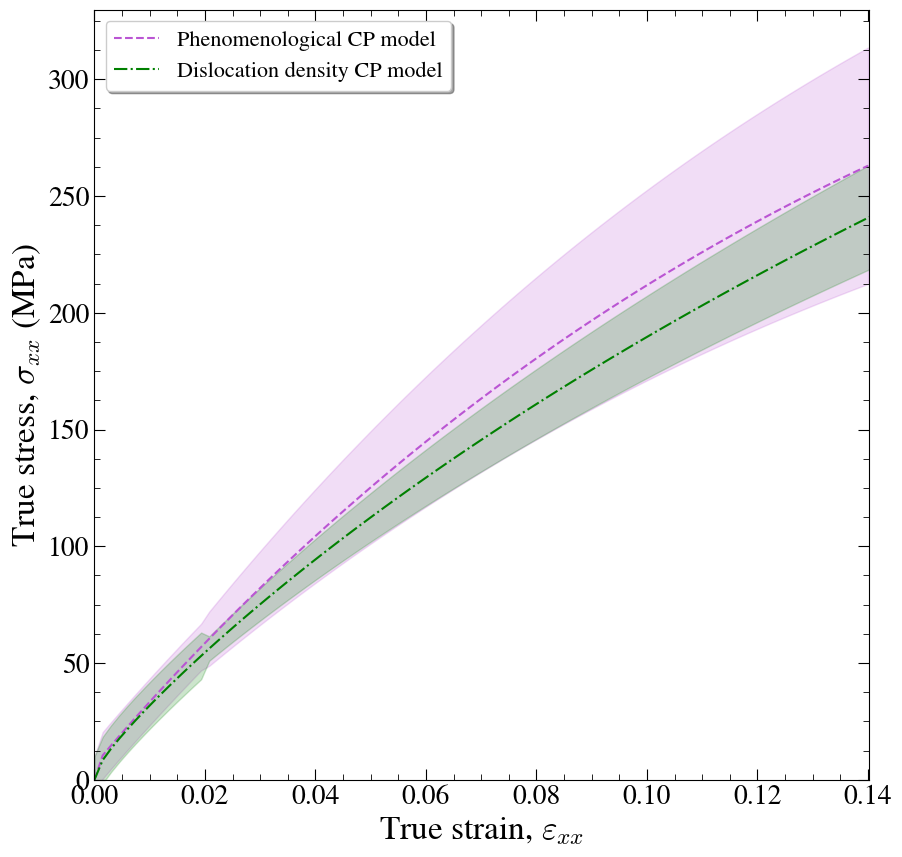

In [ ]:
%matplotlib inline
fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,1,1)

#ax.set_title('Polycrystal comparison from single crystal \n parallel calibration values', fontsize = 20, pad = 15)
ax.plot(pheno_strain, pheno_stress_MPa, label = 'Phenomenological CP model', ls = '--', marker = 'None', color = 'mediumorchid', ms = 12)
ax.plot(dislo_strain, dislo_stress_MPa, label = 'Dislocation density CP model', ls = '-.', marker = 'None', color = 'green', ms = 12)
#ax.fill_between(dislo_32_true_strain, dislo_32_true_stress_MPa - 2*dislo_exp_err, dislo_32_true_stress_MPa + 2*dislo_exp_err, color = 'green', alpha = 0.2)

#ax.fill_between(pheno_50k_true_strain, pheno_50k_true_stress_MPa - 2*pheno_exp_err, pheno_50k_true_stress_MPa + 2*pheno_exp_err, color = 'mediumorchid', alpha = 0.2)

#ax.fill_between(pheno_50k_true_strain, pheno_50k_true_stress_MPa - 9, pheno_50k_true_stress_MPa + 9, color = 'mediumorchid', alpha = 0.2)

ax.fill_between(pheno_strain, pheno_stress_MPa - 2*pheno_exp_err, pheno_stress_MPa + 2*pheno_exp_err, color = 'mediumorchid', alpha = 0.2)
ax.fill_between(dislo_strain, dislo_stress_MPa - 2*dislo_exp_err, dislo_stress_MPa + 2*dislo_exp_err, color = 'green', alpha = 0.2)

#ax.fill_between(pheno_strain, pheno_stress_MPa - 0.06*pheno_stress_MPa, pheno_stress_MPa + 0.06*pheno_stress_MPa, color = 'mediumorchid', alpha = 0.2)
#ax.fill_between(dislo_strain, dislo_stress_MPa - 0.06*dislo_stress_MPa, dislo_stress_MPa + 0.06*dislo_stress_MPa, color = 'green', alpha = 0.2)


ax.set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize = 24, math_fontfamily = 'cm')
ax.set_ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize = 24, math_fontfamily = 'cm')
ax.set_xlim(0,max(max(dislo_strain), max(pheno_strain)))
ax.set_ylim(0)
ax.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
ax.tick_params(which = 'minor', length = 4)
ax.tick_params(which = 'major', length = 8)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.legend(fontsize = 16, shadow = True)
#plt.savefig('./rolled_copper_polycrystal_stress_comparison.png', dpi=800)

# 1. Strain comparison

In [20]:
def extract_full_xx_strain(file, rve_shape):

    result = damask.Result(file)

    try:
        result.add_strain()
    
    except:
        pass

    x = result.view(increments = result.increments[-1])
    strain_map_array = x.get('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')

    return strain_map_array

In [25]:
dislo_xx_strain = extract_full_xx_strain(dislo_file, rve_shape = [128,128,128])
pheno_xx_strain = extract_full_xx_strain(pheno_file, rve_shape = [128,128,128])

np.save('dislo_128_xx_strain.npy', dislo_xx_strain)
np.save('pheno_128_xx_strain.npy', pheno_xx_strain)

/mnt/iusers01/jf01/j38714mw/software/venvs/matflow-venv/lib/python3.11/site-packages/numpy/lib/format.py:362: UserWarning: metadata on a dtype is not saved to an npy/npz. Use another format (such as pickle) to store it.
  d['descr'] = dtype_to_descr(array.dtype)


In [3]:
dislo_xx_strain_load = np.load('dislo_128_xx_strain.npy')
pheno_xx_strain_load = np.load('pheno_128_xx_strain.npy')
dislo_xx_strain_load.shape, pheno_xx_strain_load.shape

((128, 128, 128), (128, 128, 128))

In [5]:
pheno_xx_strain_flat = dislo_xx_strain_load.flatten()
dislo_xx_strain_flat = pheno_xx_strain_load.flatten()

-0.045587944376333574 0.04270426140665072


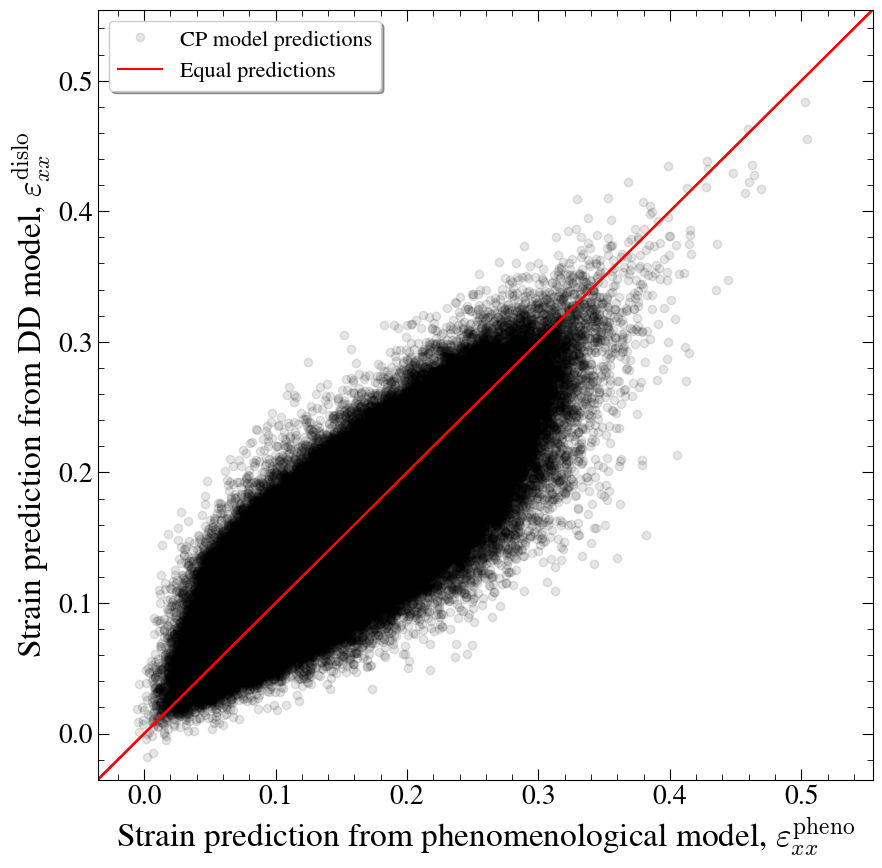

In [6]:
%matplotlib inline
comparison_utils.comparison_plot(pheno_xx_strain_flat, dislo_xx_strain_flat,
                                diag_line_start=[min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)) - np.abs(min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat))), min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)) - np.abs(min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)))],
                                min_interval=min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)) - np.abs(min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat))),
                                max_interval = max(max(pheno_xx_strain_flat), max(dislo_xx_strain_flat)) + 0.1*np.abs(max(max(pheno_xx_strain_flat), max(dislo_xx_strain_flat))),
                                xlabel = r'Strain prediction from phenomenological model, $\varepsilon_{xx}^{\text{pheno}}$',
                                ylabel = r'Strain prediction from DD model, $\varepsilon_{xx}^{\text{dislo}}$',
                                add_r2_score=False
                                )
#plt.savefig('final_VE_strain_predictions_comparison.png', dpi = 800)

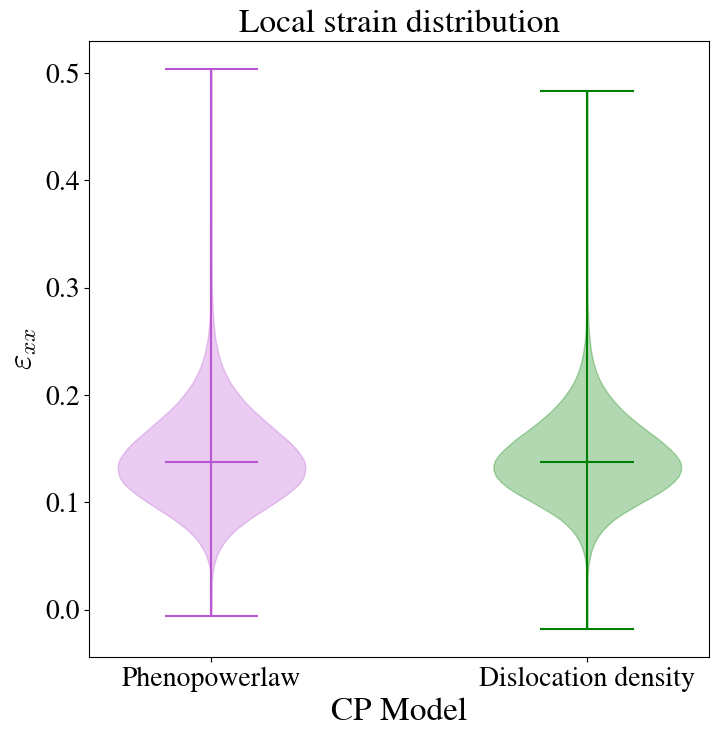

In [ ]:
%matplotlib inline
comparison_utils.violin_plot(pheno_xx_strain_flat, dislo_xx_strain_flat, title = 'Local strain distribution', qoi = r'$\varepsilon_{xx}$')
#plt.savefig('local_strain_violin_plot.png', dpi = 800)

Strain maps

In [ ]:
# test
print(pv.__file__)
print(pv.__version__)

sphere = pv.Sphere()

sphere.plot(
    screenshot="sphere.png",
    off_screen=True
)

/mnt/iusers01/jf01/j38714mw/software/venvs/matflow-venv/lib/python3.11/site-packages/pyvista/__init__.py
0.48.4


Widget(value='<iframe src="http://localhost:43293/index.html?ui=P_0x7f7805bae890_5&reconnect=auto" class="pyvi…

In [14]:
# 3D plots with pyvista

pheno_grid = pv.ImageData()
dislo_grid = pv.ImageData()

pheno_grid.dimensions = (pheno_xx_strain_load.shape[0]+1, pheno_xx_strain_load.shape[1]+1, pheno_xx_strain_load.shape[2]+1)
dislo_grid.dimensions = (dislo_xx_strain_load.shape[0]+1, dislo_xx_strain_load.shape[1]+1, dislo_xx_strain_load.shape[2]+1)

pheno_grid.cell_data["values"] = pheno_xx_strain_load.flatten(order = 'F')
dislo_grid.cell_data["values"] = dislo_xx_strain_load.flatten(order = 'F')

In [16]:
pheno_grid, dislo_grid

(ImageData (0x7f474109a320)
   N Cells:      2097152
   N Points:     2146689
   X Bounds:     0.000e+00, 1.280e+02
   Y Bounds:     0.000e+00, 1.280e+02
   Z Bounds:     0.000e+00, 1.280e+02
   Dimensions:   129, 129, 129
   Spacing:      1.000e+00, 1.000e+00, 1.000e+00
   N Arrays:     1,
 ImageData (0x7f470ee6a020)
   N Cells:      2097152
   N Points:     2146689
   X Bounds:     0.000e+00, 1.280e+02
   Y Bounds:     0.000e+00, 1.280e+02
   Z Bounds:     0.000e+00, 1.280e+02
   Dimensions:   129, 129, 129
   Spacing:      1.000e+00, 1.000e+00, 1.000e+00
   N Arrays:     1)

In [13]:
pheno_pl = pv.Plotter(notebook=True)
pheno_pl.add_volume(
    pheno_grid,
    scalars = 'values',
    cmap = 'viridis',
    opacity = 1
)

pheno_pl.show(screenshot="pheno_VE_volume.png")

Widget(value='<iframe src="http://localhost:38611/index.html?ui=P_0x7f470fcb9110_6&reconnect=auto" class="pyvi…

In [35]:
pheno_surface_slice_xy = pheno_grid.slice_orthogonal(
    z = 0
)

print(pheno_surface_slice_xy)

pheno_slice_pl = pv.Plotter()

pheno_slice_pl.add_mesh(
    pheno_surface_slice_xy,
    scalars="values",
    cmap="viridis",
    opacity = 1
)

pheno_slice_pl.show(screenshot = "pheno_VE_surface_xy.png")


MultiBlock (0x7f46ef886860)
  N Blocks:   3
  X Bounds:   0.000e+00, 1.280e+02
  Y Bounds:   0.000e+00, 1.280e+02
  Z Bounds:   0.000e+00, 1.280e+02


Widget(value='<iframe src="http://localhost:38611/index.html?ui=P_0x7f46e92f4650_24&reconnect=auto" class="pyv…

In [20]:
dislo_pl = pv.Plotter()
dislo_pl.add_volume(
    dislo_grid,
    scalars = "values",
    cmap = 'viridis',
    opacity = 1
)
dislo_pl.show(screenshot = "dislo_VE_volume.png")

Widget(value='<iframe src="http://localhost:38611/index.html?ui=P_0x7f4722516bd0_11&reconnect=auto" class="pyv…

2D

In [19]:
pheno_xx_surface_strain = pheno_xx_strain_load[:,:,0].transpose()
dislo_xx_surface_strain = dislo_xx_strain_load[:,:,0].transpose()

pheno_xx_surface_strain_flip = np.flip(pheno_xx_surface_strain, axis=0)
dislo_xx_surface_strain_flip = np.flip(dislo_xx_surface_strain, axis=0)

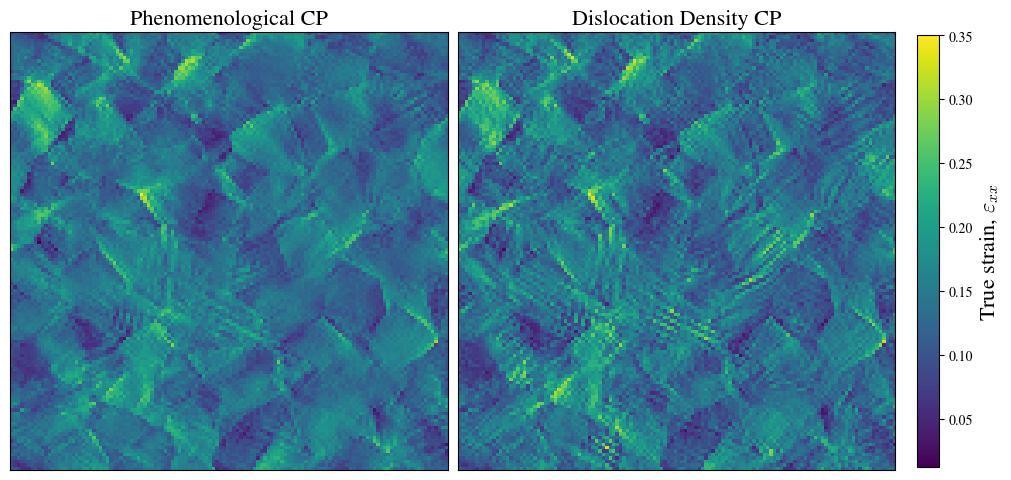

In [ ]:
%matplotlib inline

fig_load_strain, ax_load_strain = plt.subplots(1,2, figsize = (10,6), sharey = True, sharex=True, constrained_layout=True)

pheno_load_strain_im = ax_load_strain[0].imshow(pheno_xx_surface_strain_flip, vmin = min(min(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())), vmax = max(max(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())))
dislo_load_strain_im = ax_load_strain[1].imshow(dislo_xx_surface_strain_flip, vmin = min(min(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())), vmax = max(max(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())))
#cbar1 = fig.colorbar(pheno_strain_im, orientation = 'vertical')
cbar_load = fig_load_strain.colorbar(dislo_load_strain_im, orientation = 'vertical', shrink = 0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_load.set_label(r'True strain, $\varepsilon_{xx}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
ax_load_strain[0].set_title('Phenomenological CP', fontsize = 16)
ax_load_strain[1].set_title('Dislocation Density CP', fontsize = 16)
ax_load_strain[0].set_xticks([])
ax_load_strain[1].set_xticks([])
ax_load_strain[0].set_yticks([])
ax_load_strain[1].set_yticks([])
#plt.savefig('surface_strain_comparison.png', dpi = 800)

In [15]:
def extract_strain_maps(file, rve_shape, layer, direction):

    '''
    Extract and plot strain maps from DAMASK HDF5 file

    direction: {'xy', 'yz', 'xz'}
        
    '''

    result = damask.Result(file)

    try:
        result.add_strain()
        result.add_stress_Cauchy()
        result.add_IPF_color(l=(0,0,1))

    except:
        pass

    increment = result.increments[-1]

    x = result.view(increments = increment)
 
    if direction == 'xy':
        strain_map_array = x.place('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')[:,:,layer].transpose()

    if direction == 'yz':
        strain_map_array = x.place('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')[layer,:,:].transpose()

    if direction == 'xz':
        strain_map_array = x.place('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')[:,layer,:].transpose()

    strain_map_array_flip_y = np.flip(strain_map_array, axis=0)
    #strain_map_array_flipped = np.flip(strain_map_array_flip_y, axis=1)

    return strain_map_array_flip_y

In [16]:
pheno_strain_map_surface = extract_strain_maps(pheno_file, [128,128,128], layer = 0, direction = 'xy')
dislo_strain_map_surface = extract_strain_maps(dislo_file, [128,128,128], layer = 0, direction = 'xy')

In [82]:
pheno_strain_map_central = extract_strain_maps(pheno_file, [128,128,128], layer = 15, direction = 'xy')
dislo_strain_map_central = extract_strain_maps(dislo_file, [128,128,128], layer = 15, direction = 'xy')

[]

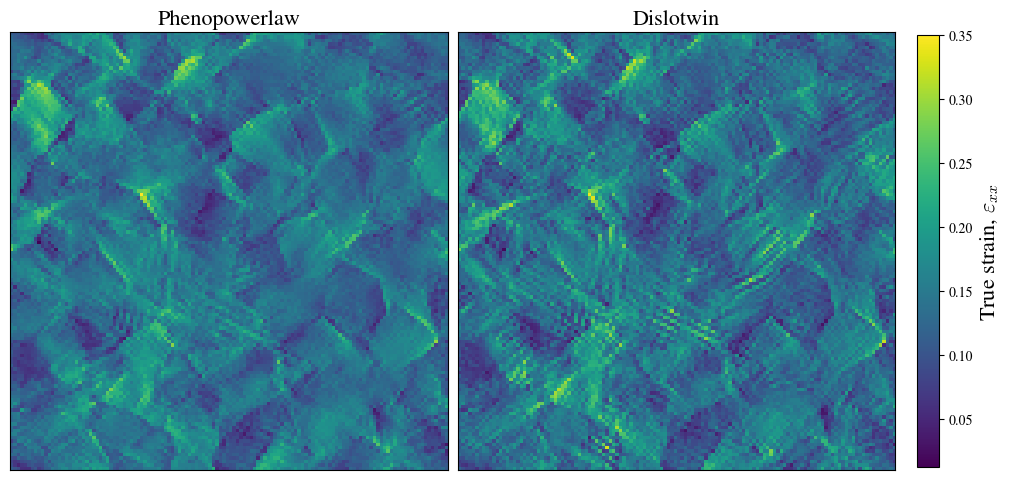

In [18]:
%matplotlib inline

fig_strain, ax_strain = plt.subplots(1,2, figsize = (10,6), sharey = True, sharex=True, constrained_layout=True)

pheno_strain_im = ax_strain[0].imshow(pheno_strain_map_surface, vmin = min(min(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())), vmax = max(max(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())))
dislo_strain_im = ax_strain[1].imshow(dislo_strain_map_surface, vmin = min(min(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())), vmax = max(max(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())))
#cbar1 = fig.colorbar(pheno_strain_im, orientation = 'vertical')
cbar2 = fig_strain.colorbar(dislo_strain_im, orientation = 'vertical', shrink = 0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar2.set_label(r'True strain, $\varepsilon_{xx}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
ax_strain[0].set_title('Phenopowerlaw', fontsize = 16)
ax_strain[1].set_title('Dislotwin', fontsize = 16)
ax_strain[0].set_xticks([])
ax_strain[1].set_xticks([])
ax_strain[0].set_yticks([])
ax_strain[1].set_yticks([])

# 2. Stress triaxiality

In [23]:
def calc_full_xx_triaxiality(file, rve_shape):
    result = damask.Result(file)

    x = result.view(increments = result.increments[-1])

    print(x)
    
    #x.add_spherical('sigma')
    #x.add_equivalent_Mises('sigma')

    hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')
    vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')

    print(hydrostatic_stress.shape, vM_stress.shape)

    triaxiality = hydrostatic_stress/vM_stress

    return triaxiality

In [52]:
pheno_triax = calc_full_xx_triaxiality(pheno_file, [128,128,128])
np.save('pheno_triax.npy', pheno_triax)

Created by /usr/bin/DAMASK_grid v3.0.2
        on 2026-06-22 14:30:20+0100
 executing "/usr/bin/DAMASK_grid --jobname geom_load --load load.yaml --geom geom.vti --material material.yaml --numerics numerics.yaml"

increment_5000 (49.999999999999 s)
  phase
    Cu
      mechanical
        F / 1: deformation gradient
        F_p / 1: plastic deformation gradient
        L_p / 1/s: plastic velocity gradient
        O / 1: crystal orientation as quaternion q_0 (q_1 q_2 q_3)
        P / Pa: first Piola-Kirchhoff stress
        epsilon_V^0(F) / 1: Seth-Hill strain tensor of order 0 based on left stretch tensor of F (deformation gradient)
        gamma_sl / 1: plastic shear
        p_sigma / Pa: spherical component of tensor sigma (Cauchy stress calculated from P (first Piola-Kirchhoff stress) and F (deformation gradient))
        sigma / Pa: Cauchy stress calculated from P (first Piola-Kirchhoff stress) and F (deformation gradient)
        sigma_vM / Pa: Mises equivalent stress of sigma (Cauc

/mnt/iusers01/jf01/j38714mw/software/venvs/matflow-venv/lib/python3.11/site-packages/numpy/lib/format.py:362: UserWarning: metadata on a dtype is not saved to an npy/npz. Use another format (such as pickle) to store it.
  d['descr'] = dtype_to_descr(array.dtype)


In [53]:
dislo_triax = calc_full_xx_triaxiality(dislo_file, [128,128,128])
np.save('dislo_triax.npy', dislo_triax)

Created by /usr/bin/DAMASK_grid v3.0.2
        on 2026-06-22 14:29:18+0100
 executing "/usr/bin/DAMASK_grid --jobname geom_load --load load.yaml --geom geom.vti --material material.yaml --numerics numerics.yaml"

increment_5000 (49.999999999999 s)
  phase
    Cu
      mechanical
        F / 1: deformation gradient
        F_p / 1: plastic deformation gradient
        IPFcolor_(0 0 1) / 8-bit RGB: Inverse Pole Figure (IPF) colors along sample direction (0 0 1)
        L_p / 1/s: plastic velocity gradient
        O / 1: crystal orientation as quaternion q_0 (q_1 q_2 q_3)
        P / Pa: first Piola-Kirchhoff stress
        epsilon_V^0(F) / 1: Seth-Hill strain tensor of order 0 based on left stretch tensor of F (deformation gradient)
        gamma_sl / 1: plastic shear
        p_sigma / Pa: spherical component of tensor sigma (Cauchy stress calculated from P (first Piola-Kirchhoff stress) and F (deformation gradient))
        rho_mob / 1/m²: mobile dislocation density
        sigma / Pa: 

In [4]:
pheno_triax_load = np.load('pheno_triax.npy')
dislo_triax_load = np.load('dislo_triax.npy')

In [9]:
pheno_triax_flat = pheno_triax_load.flatten()
dislo_triax_flat = dislo_triax_load.flatten()

-0.2992888872959151 0.3135284222554232


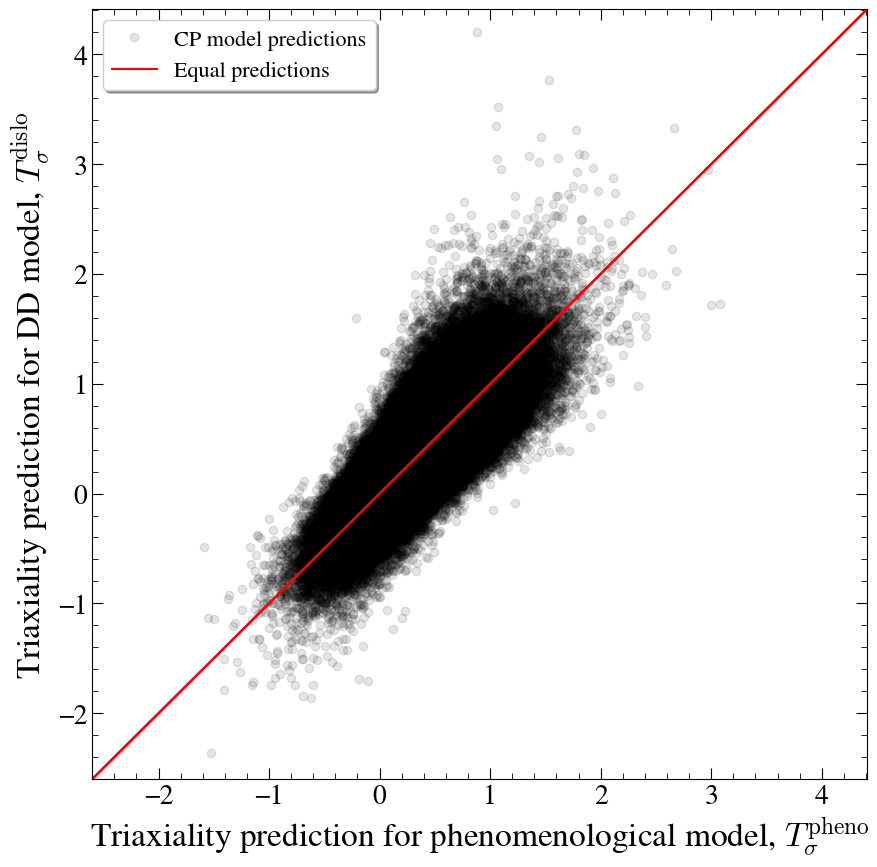

In [12]:
comparison_utils.comparison_plot(pheno_triax_flat, dislo_triax_flat,
                diag_line_start=[min(min(pheno_triax_flat), min(dislo_triax_flat)) - 0.1*np.abs(min(min(pheno_triax_flat), min(dislo_triax_flat))), min(min(pheno_triax_flat), min(dislo_triax_flat)) - 0.1*np.abs(min(min(pheno_triax_flat), min(dislo_triax_flat)))],
                min_interval = min(min(pheno_triax_flat), min(dislo_triax_flat)) - 0.1*np.abs(min(min(pheno_triax_flat), min(dislo_triax_flat))),
                max_interval = max(max(pheno_triax_flat), max(dislo_triax_flat)) + 0.05*np.abs(max(max(pheno_triax_flat), max(dislo_triax_flat))),
                xlabel = r'Triaxiality prediction for phenomenological model, $T_{\sigma}^{\text{pheno}}$',
                ylabel = r'Triaxiality prediction for DD model, $T_{\sigma}^{\text{dislo}}$',
                add_r2_score= False
                )
plt.savefig('final_VE_triaxiality_predictions_comparison.png', dpi = 800)

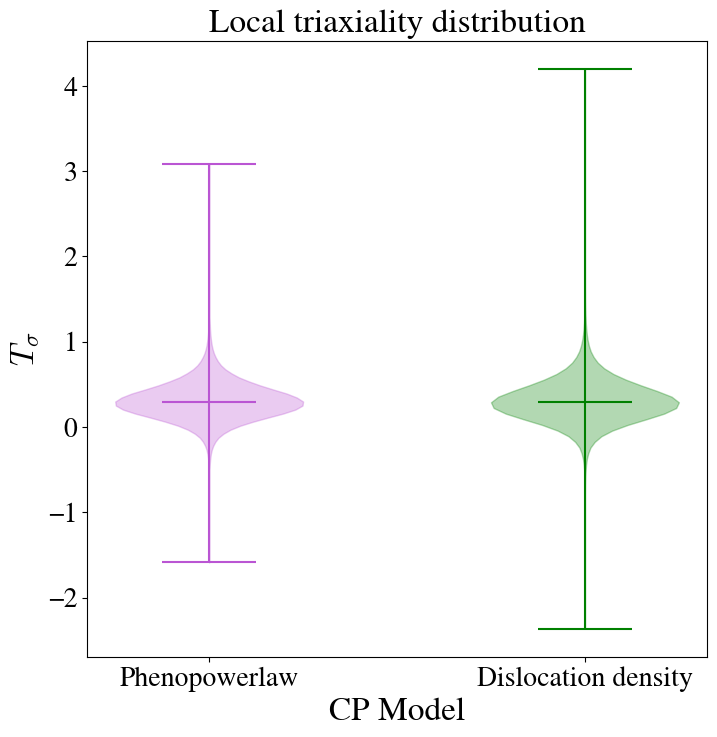

In [60]:
comparison_utils.violin_plot(pheno_triax_flat, dislo_triax_flat, title = 'Local triaxiality distribution', qoi = r'$T_{\sigma}$')
plt.savefig('stress_triax_violin_plot.png', dpi=800)

# 3D maps from pyvista

In [40]:
pheno_triax_grid = pv.ImageData()
dislo_triax_grid = pv.ImageData()

pheno_triax_grid.dimensions = (pheno_triax_load.shape[0]+1, pheno_triax_load.shape[1]+1, pheno_triax_load.shape[2]+1)
dislo_triax_grid.dimensions = (dislo_triax_load.shape[0]+1, dislo_triax_load.shape[1]+1, dislo_triax_load.shape[2]+1)

pheno_triax_grid.cell_data["triax_values"] = pheno_triax_load.flatten(order = 'F')
dislo_triax_grid.cell_data["triax_values"] = dislo_triax_load.flatten(order = 'F')

In [46]:
max(pheno_triax_load.flatten()), max(dislo_triax_load.flatten())

(3.079690866754879, 4.200635413902881)

In [48]:
triax_pl = pv.Plotter(shape = (1,2))

triax_pl.subplot(0,0)
triax_pl.add_volume(
    pheno_triax_grid,
    scalars = 'triax_values',
    cmap = 'viridis',
    opacity = 1,
    clim = [min(min(pheno_triax_load.flatten()), min(dislo_triax_load.flatten())), max(max(pheno_triax_load.flatten()), max(dislo_triax_load.flatten()))],
    scalar_bar_args={"title": r"Triaxiality, T_{\sigma}"}
)
triax_pl.add_text("Phenomenological CP")

triax_pl.subplot(0,1)
triax_pl.add_volume(
    dislo_triax_grid,
    scalars = 'triax_values',
    cmap = 'viridis',
    opacity = 1,
    clim = [min(min(pheno_triax_load.flatten()), min(dislo_triax_load.flatten())), max(max(pheno_triax_load.flatten()), max(dislo_triax_load.flatten()))],
    show_scalar_bar=False
)
triax_pl.add_text("Dislocation density CP")

triax_pl.show(screenshot="VEs_triax.png")

Widget(value='<iframe src="http://localhost:38611/index.html?ui=P_0x7f46dcc8a410_29&reconnect=auto" class="pyv…

Difference between CP models

In [ ]:
triax_3d_diff = dislo_triax_load - pheno_triax_load
triax_diff_grid = pv.ImageData()
triax_diff_grid.dimensions = (triax_3d_diff.shape[0]+1, triax_3d_diff.shape[1]+1, triax_3d_diff.shape[2]+1)
triax_diff_grid.cell_data["triax_values"] = triax_3d_diff.flatten(order = 'F')

triax_diff_pl = pv.Plotter()
triax_diff_pl.add_volume(
    triax_diff_grid,
    scalars = 'triax_values',
    cmap = 'coolwarm',
    opacity = 1,
    scalar_bar_args={"title": r"Triaxiality, T"})

triax_diff_pl.show(screenshot="VE_triax_diff.png")

128


Widget(value='<iframe src="http://localhost:38611/index.html?ui=P_0x7f46bfda6f50_31&reconnect=auto" class="pyv…

In [32]:
dislo_triax_load_flat = dislo_triax_load.flatten()
pheno_triax_load_flat = pheno_triax_load.flatten()
print(dislo_triax_load_flat.max(), pheno_triax_load_flat.max())

for i in range(len(pheno_triax_load_flat)):
    if (dislo_triax_load_flat[i] > 0 and pheno_triax_load_flat[i] > 0) or (dislo_triax_load_flat[i] < 0 and pheno_triax_load_flat[i] < 0) :
        pheno_triax_load_flat[i] = np.nan
        dislo_triax_load_flat[i] = np.nan

triax_largest_diff_flat = np.empty(len(pheno_triax_load_flat))
triax_largest_diff_flat[:] = np.nan

for i in range(len(pheno_triax_load_flat)):
    if not np.isnan(pheno_triax_load_flat[i]):
        if pheno_triax_load_flat[i] > dislo_triax_load_flat[i]:
            triax_largest_diff_flat[i] = pheno_triax_load_flat[i] - dislo_triax_load_flat[i]
        elif dislo_triax_load_flat[i] > pheno_triax_load_flat[i]:
            triax_largest_diff_flat[i] = dislo_triax_load_flat[i] - pheno_triax_load_flat[i]
print(triax_largest_diff_flat)

4.200635413902881 3.079690866754879
[nan nan nan ... nan nan nan]


In [28]:
def not_nan_counter(data):
    count = 0       
    # loop over each entry of the data
    for entry in data:          
        if not np.isnan(entry):     
            count += 1              
    return count

In [33]:
not_nan_counter(triax_largest_diff_flat)

148498

In [34]:
triax_largest_diff_opp = triax_largest_diff_flat.reshape([128,128,128])

In [40]:
148498/(128**3)

0.07080936431884766

In [42]:
triax_largest_diffs_grid = pv.ImageData()
triax_largest_diffs_grid.dimensions = (triax_largest_diff_opp.shape[0]+1, triax_largest_diff_opp.shape[1]+1, triax_largest_diff_opp.shape[2]+1)
triax_largest_diffs_grid.cell_data["triax_values"] = triax_largest_diff_opp.flatten(order = 'F')
triax_largest_diffs_grid_no_nan = triax_largest_diffs_grid.threshold([-np.inf, np.inf], scalars="triax_values")

triax_diff_pl = pv.Plotter()
triax_diff_pl.add_volume(
    triax_largest_diffs_grid_no_nan,
    scalars = 'triax_values',
    cmap = 'cool',
    opacity = 'linear',
    scalar_bar_args={"title": r"Triaxiality, T"})

triax_diff_pl.show(screenshot="VE_triax_largest_diffs_no_nans.png")

Widget(value='<iframe src="http://localhost:43285/index.html?ui=P_0x7f3bfdefa650_4&reconnect=auto" class="pyvi…

In [41]:
triax_largest_diffs_grid.n_cells, triax_largest_diffs_grid_no_nan.n_cells

(2097152, 148498)

# Using initial easy triax extraction for map plotting

In [49]:
#pheno_surface_triax = pheno_triax[:,:,0].transpose()
pheno_surface_triax = pheno_triax_load[:,:,0].transpose()
#dislo_surface_triax = dislo_triax[:,:,0].transpose()
dislo_surface_triax = dislo_triax_load[:,:,0].transpose()

pheno_surface_triax_flip = np.flip(pheno_surface_triax, axis=0)
dislo_surface_triax_flip = np.flip(dislo_surface_triax, axis=0)

[]

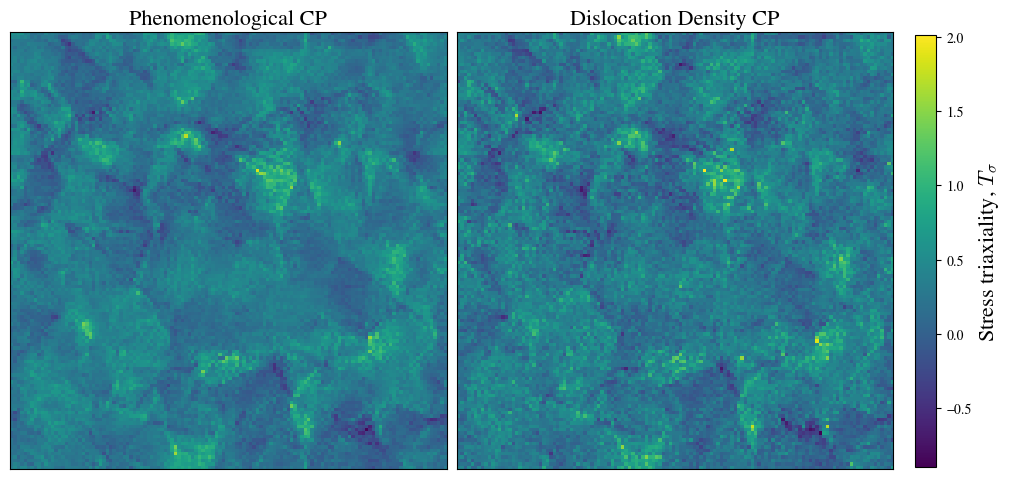

In [50]:
%matplotlib inline

fig_load_triax, ax_load_triax = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_load_triax_im = ax_load_triax[0].imshow(pheno_surface_triax_flip, vmin = min(min(value) for value in (pheno_surface_triax_flip.flatten(), dislo_surface_triax_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_triax_flip.flatten(), dislo_surface_triax_flip.flatten())))
dislo_load_triax_im = ax_load_triax[1].imshow(dislo_surface_triax_flip, vmin = min(min(value) for value in (pheno_surface_triax_flip.flatten(), dislo_surface_triax_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_triax_flip.flatten(), dislo_surface_triax_flip.flatten())))
cbar_load_triax = fig_load_triax.colorbar(dislo_load_triax_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_load_triax.set_label(r'Stress triaxiality, $T_{\sigma}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
#ax_load_triax[0].annotate(text = 'Layer 0, XY', xy = [1,7], color = 'w', fontsize = 20)
ax_load_triax[0].set_title('Phenomenological CP', fontsize = 16)
ax_load_triax[1].set_title('Dislocation Density CP', fontsize = 16)
ax_load_triax[0].set_xticks([])
ax_load_triax[1].set_xticks([])
ax_load_triax[0].set_yticks([])
ax_load_triax[1].set_yticks([])
#plt.savefig('surface_stress_triax_comparison.png', dpi = 800)

/tmp/ipykernel_183307/683045756.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 1000x600 with 3 Axes> which fig.colorbar is called on.
  cbar_triax_diff = fig_load_triax.colorbar(triax_diff_im, orientation = 'vertical', shrink = 0.8)


[]

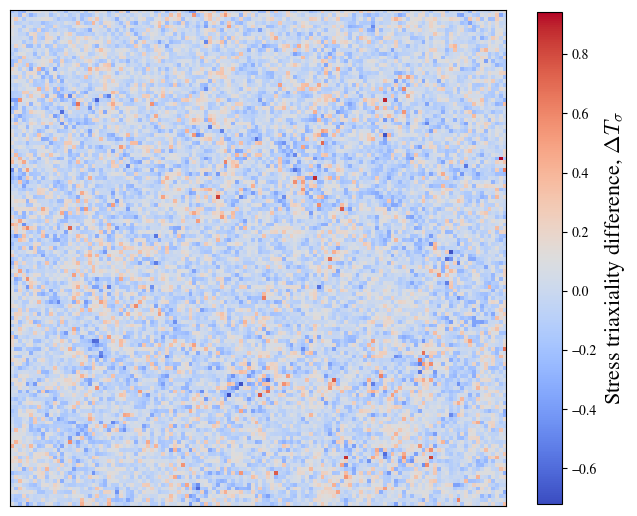

In [56]:
# Difference plot
triax_diff = dislo_surface_triax_flip - pheno_surface_triax_flip
fig_triax_diff, ax_triax_diff = plt.subplots(1,1, figsize = (8,8))

triax_diff_im = ax_triax_diff.imshow(triax_diff, cmap = 'coolwarm')
cbar_triax_diff = fig_load_triax.colorbar(triax_diff_im, orientation = 'vertical', shrink = 0.8)
cbar_triax_diff.set_label(r'Stress triaxiality difference, $\Delta T_{\sigma}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
ax_triax_diff.set_xticks([])
ax_triax_diff.set_yticks([])

In [128]:
def calc_triaxiality_2D(file, rve_shape, layer, direction):
    result = damask.Result(file)

    try:
        result.add_spherical('sigma')
        result.add_equivalent_Mises('sigma')
        
    except:
        pass

    x = result.view(increments = result.increments[-1])

    if direction == 'xy':
        hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')[:,:,layer].transpose()
        vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')[:,:,layer].transpose()
        
    if direction == 'yz':
        hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')[layer,:,:].transpose()
        vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')[layer,:,:].transpose()

    if direction == 'xz':
        hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')[:,layer,:].transpose()
        vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')[:,layer,:].transpose()

    hydrostatic_stress_flipped = np.flip(hydrostatic_stress, axis=0)
    vM_stress_flipped = np.flip(vM_stress, axis=0)

    triaxiality = hydrostatic_stress_flipped/vM_stress_flipped

    return triaxiality

In [134]:
pheno_triax_surface_layer = calc_triaxiality_2D(pheno_file, rve_shape = [128,128,128], layer = 0, direction = 'xy')
print('Pheno map extracted!')
dislo_triax_surface_layer = calc_triaxiality_2D(dislo_file, rve_shape = [128,128,128], layer = 0, direction = 'xy')
print('Dislo map extracted!')

[]

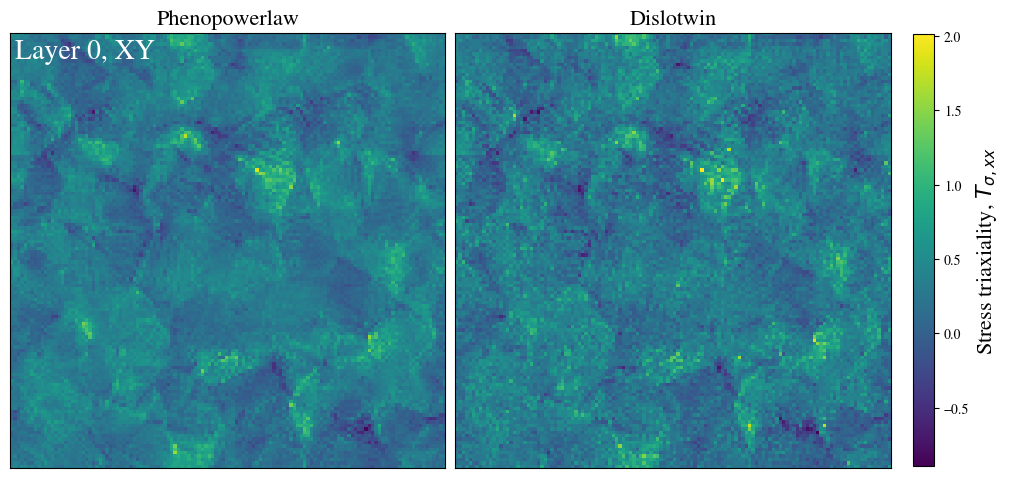

In [135]:
%matplotlib inline

fig_triax, ax_triax = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_triax_im = ax_triax[0].imshow(pheno_triax_surface_layer, vmin = min(min(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())), vmax = max(max(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())))
dislo_triax_im = ax_triax[1].imshow(dislo_triax_surface_layer, vmin = min(min(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())), vmax = max(max(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())))
cbar_triax = fig_triax.colorbar(dislo_triax_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_triax.set_label('Stress triaxiality, $T_{\sigma,xx}$', rotation = 90, fontsize = 16)
ax_triax[0].annotate(text = 'Layer 0, XY', xy = [1,7], color = 'w', fontsize = 20)
ax_triax[0].set_title('Phenopowerlaw', fontsize = 16)
ax_triax[1].set_title('Dislotwin', fontsize = 16)
ax_triax[0].set_xticks([])
ax_triax[1].set_xticks([])
ax_triax[0].set_yticks([])
ax_triax[1].set_yticks([])

# 3. Plastic work

In [49]:
def calc_plastic_work_full(damask_file, mat_file, rve_shape, full = True, slip_system = None):
    result = damask.Result(damask_file)
    x = result.view(increments = result.increments[-1])

    if full == True:
        rve_shape_ext = [128,128,128,12]
        #gamma = x.place('gamma_sl')
        gamma = x.get('gamma_sl').reshape(rve_shape_ext, order = 'F')
    if full == False:
        #gamma = x.place('gamma_sl')[:,slip_system]
        gamma = x.get('gamma_sl')[:,slip_system].reshape(rve_shape, order = 'F')

    mat = damask.ConfigMaterial.load(mat_file)
    crystal_structure = damask.Crystal(lattice = mat['phase']['Cu']['lattice'])

    if full == True:
        slip_dirs = crystal_structure.kinematics('slip')['direction'][0]
        slip_norms = crystal_structure.kinematics('slip')['plane'][0]

    if full == False:
        slip_dirs = crystal_structure.kinematics('slip')['direction'][0][slip_system]
        slip_norms = crystal_structure.kinematics('slip')['plane'][0][slip_system]

    #print(slip_dirs, slip_norms)

    rot_matrices = damask.Rotation(x.get('O')).reshape(rve_shape, order = 'F').as_matrix()
    #print(len(rot_matrices))

    # Calculate final orientations of material points

    all_new_slip_dirs = []
    all_new_slip_norms = []

    for i in range(len(rot_matrices)):
        new_slip_dirs = []
        new_slip_norms = []
        for j in range(len(slip_dirs)):
            new_slip_dir = rot_matrices[i] @ slip_dirs[j]
            new_slip_norm = rot_matrices[i] @ slip_norms[j]
            new_slip_dirs.append(new_slip_dir)
            new_slip_norms.append(new_slip_norm)
        
        all_new_slip_dirs.append(new_slip_dirs)
        all_new_slip_norms.append(new_slip_norms)

    sigma = x.get('sigma').reshape([128,128,128,3,3], order = 'F')

    print(np.array(sigma.shape), np.array(all_new_slip_dirs).shape, np.array(all_new_slip_norms).shape)
    
    # Calculate resolved shear stresses
    tau = np.einsum('vij,vsi,vsj->vs', sigma, all_new_slip_dirs, all_new_slip_norms)
    #print(tau.shape)

    if full == True:
        tau_slip = tau.reshape(rve_shape_ext, order = 'F')

    if full == False:
        tau_slip = tau[:,slip_system].reshape(rve_shape, order = 'F').transpose()

    plastic_work = np.multiply(gamma, tau_slip)

    return plastic_work

In [50]:
pheno_mat_file = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_128_rolled_copper_5k_time_steps_2026-06-22_142935/execute/t_1/material.yaml'
dislo_mat_file = './dislo_density/second_year_report_calibrated_values/dislotwin_128_rolled_copper_5k_time_steps_2026-06-22_142808/execute/t_1/material.yaml'

In [51]:
pheno_plastic_work_full = calc_plastic_work_full(pheno_file, pheno_mat_file, rve_shape=[128,128,128])

[128 128 128   3   3] (128, 12, 128, 128, 3) (128, 12, 128, 128, 3)


ValueError: operand has more dimensions than subscripts given in einstein sum, but no '...' ellipsis provided to broadcast the extra dimensions.

In [ ]:
dislo_plastic_work_full = calc_plastic_work_full(dislo_file, dislo_mat_file, rve_shape=[128,128,128])

# 4. r-value

In [39]:
# Option 1, r-value from local plastic strain

def calc_r_value(damask_file):
    result = damask.Result(damask_file)

    r_values = []    
    eq_values = []

    increments = result.increments[::5]

    print(result)

    for inc in increments:    
        r_inc = result.view(increments=inc) 
        eps = next(iter(r_inc.get('epsilon_U^0.0(F_p)')))   
        #eps_avg = np.mean(eps, axis=0)
        #print(eps)
        r_values.append(eps[1,1] / eps[2,2])

        U = next(iter(r_inc.get('U(F_p)')))
        #print(U)
        #U_avg = np.mean(U, axis=0)
        eps_from_U = damask.mechanics.strain(U, t='U', m=0.0)
        eps_vM = damask.mechanics.equivalent_strain_Mises(eps_from_U)
        eq_values.append(eps_vM)

    #plastic_strain = np.array([np.average(eps,0) for eps in result.get('epsilon_U^0.0(F_p)').values()])
    #r_eps_p = plastic_strain[:,1,1]/plastic_strain[:,2,2]

    #U_p_avg = np.array([np.average(U_p,0) for U_p in result.get('U(F_p)').values()])
    #epsilon_F_p_avg = damask.mechanics.strain(U_p_avg,t='U',m=0.0)
    #epsilon_F_p_vM_avg = damask.mechanics.equivalent_strain_Mises(epsilon_F_p_avg)

    return np.asarray(eq_values), np.asarray(r_values) #epsilon_F_p_vM_avg, r_eps_p

In [23]:
pheno_vM_strain, pheno_r_val = calc_r_value(pheno_file)

[[-1.11022302e-16  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -9.47125670e-17 -1.50250296e-16]
 [ 0.00000000e+00 -1.50250296e-16 -2.38354340e-16]]
[[ 1.00000000e+00  0.00000000e+00  1.38777878e-16]
 [-5.55111512e-17  1.00000000e+00  0.00000000e+00]
 [-5.55111512e-17  5.55111512e-17  1.00000000e+00]]
[[ 0.00576851  0.00403     0.00037921]
 [ 0.00403    -0.00176552 -0.004116  ]
 [ 0.00037921 -0.004116   -0.004003  ]]
[[ 1.00579340e+00  4.03733051e-03  3.71259636e-04]
 [ 4.03733051e-03  9.98252612e-01 -4.10340196e-03]
 [ 3.71259636e-04 -4.10340196e-03  9.96013519e-01]]
[[ 0.01163558  0.00818256  0.00074185]
 [ 0.00818256 -0.00348291 -0.00831676]
 [ 0.00074185 -0.00831676 -0.00815266]]
[[ 1.01173749e+00  8.21316230e-03  7.09143074e-04]
 [ 8.21316230e-03  9.96591070e-01 -8.26567271e-03]
 [ 7.09143074e-04 -8.26567271e-03  9.91915094e-01]]
[[ 0.01736423  0.01230247  0.00110865]
 [ 0.01230247 -0.00509891 -0.01243804]
 [ 0.00110865 -0.01243804 -0.01226532]]
[[ 1.01759286  0.01237214  0.0

In [38]:
dislo_test_result = damask.Result(dislo_file)
try:
    dislo_test_result.add_strain('F_p','U')
    dislo_test_result.add_stretch_tensor('F_p',t='U')
except:
    pass

In [41]:
dislo_test_result

Created by /usr/bin/DAMASK_grid v3.0.2
        on 2026-06-22 14:29:18+0100
 executing "/usr/bin/DAMASK_grid --jobname geom_load --load load.yaml --geom geom.vti --material material.yaml --numerics numerics.yaml"

increment_0 (0.0 s)
  phase
    Cu
      mechanical
        F / 1: deformation gradient
        F_p / 1: plastic deformation gradient
        IPFcolor_(0 0 1) / 8-bit RGB: Inverse Pole Figure (IPF) colors along sample direction (0 0 1)
        L_p / 1/s: plastic velocity gradient
        O / 1: crystal orientation as quaternion q_0 (q_1 q_2 q_3)
        P / Pa: first Piola-Kirchhoff stress
        epsilon_U^0.0(F_p) / 1: Seth-Hill strain tensor of order 0.0 based on right stretch tensor of F_p (plastic deformation gradient)
        epsilon_V^0(F) / 1: Seth-Hill strain tensor of order 0 based on left stretch tensor of F (deformation gradient)
        epsilon_V^0.0(F) / 1: Seth-Hill strain tensor of order 0.0 based on left stretch tensor of F (deformation gradient)
        gamma

In [40]:
dislo_vM_strain, dislo_r_val = calc_r_value(dislo_file)

Created by /usr/bin/DAMASK_grid v3.0.2
        on 2026-06-22 14:29:18+0100
 executing "/usr/bin/DAMASK_grid --jobname geom_load --load load.yaml --geom geom.vti --material material.yaml --numerics numerics.yaml"

increment_0 (0.0 s)
  phase
    Cu
      mechanical
        F / 1: deformation gradient
        F_p / 1: plastic deformation gradient
        IPFcolor_(0 0 1) / 8-bit RGB: Inverse Pole Figure (IPF) colors along sample direction (0 0 1)
        L_p / 1/s: plastic velocity gradient
        O / 1: crystal orientation as quaternion q_0 (q_1 q_2 q_3)
        P / Pa: first Piola-Kirchhoff stress
        epsilon_U^0.0(F_p) / 1: Seth-Hill strain tensor of order 0.0 based on right stretch tensor of F_p (plastic deformation gradient)
        epsilon_V^0(F) / 1: Seth-Hill strain tensor of order 0 based on left stretch tensor of F (deformation gradient)
        epsilon_V^0.0(F) / 1: Seth-Hill strain tensor of order 0.0 based on left stretch tensor of F (deformation gradient)
        gamma

TypeError: 'NoneType' object is not iterable

In [26]:
np.save("pheno_128_vM_strain.npy",pheno_vM_strain)
#np.save("dislo_128_vM_strain.npy",dislo_vM_strain)
np.save("pheno_128_vM_r_val.npy",pheno_r_val)
#np.save("dislo_128_vM_r_val.npy",dislo_r_val)

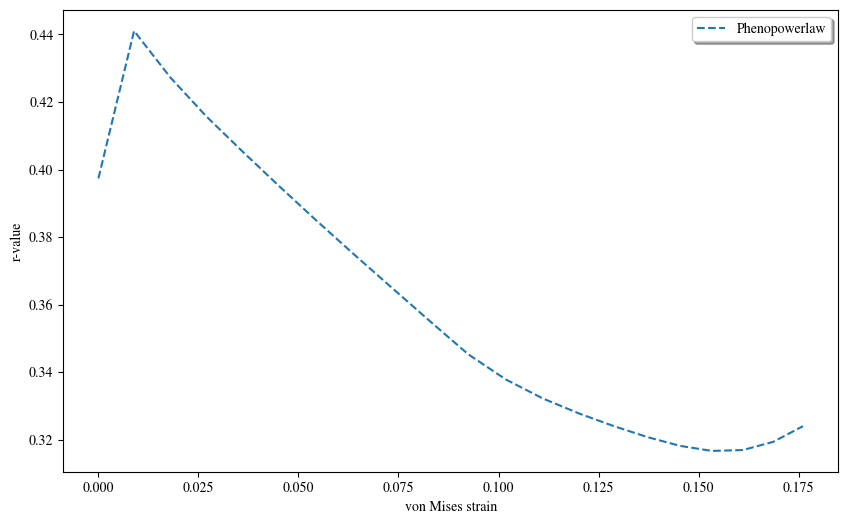

In [29]:
%matplotlib inline
fig_r_val, ax_r_val = plt.subplots(1,1, figsize = (10,6))

ax_r_val.plot(pheno_vM_strain, pheno_r_val, ls = '--', label = 'Phenopowerlaw')
#ax_r_val.plot(dislo_vM_strain, dislo_r_val, ls = '-', label = 'Dislotwin')
ax_r_val.set_xlabel('von Mises strain')
ax_r_val.set_ylabel('r-value')

ax_r_val.legend(shadow = True)